# PFC: Grain Boundary Evolution

## Laplacian Operator 

(Lin, before Friday)

The finite difference method can be adopted to express the laplacian operator $\nabla^2$ on a discrete mesh in terms of $\phi(i,j)$, i.e., $\nabla^2=\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}$. This can be done using a Taylor series since the neighours are on the order of $dx \sim dy \ll 1$, expanding $\phi(i,j)$ around mesh point $(i,j)$[1]:

\begin{align}
\phi(i\pm 1,j) &= \phi(i,j) \pm \frac{\partial \phi}{\partial x}dx +\frac{1}{2}\frac{\partial^2 \phi}{\partial x^2}dx^2 \\
\phi(i,j\pm 1) &= \phi(i,j) \pm \frac{\partial \phi}{\partial y}dy +\frac{1}{2}\frac{\partial^2 \phi}{\partial y^2}dy^2 \\
\phi(i\pm 1,j\pm 1) &= \phi(i,j) \pm \frac{\partial \phi}{\partial x}dx \pm \frac{\partial \phi}{\partial y}dy +\frac{1}{2}\frac{\partial^2 \phi}{\partial x^2}dx^2 +\frac{1}{2}\frac{\partial^2 \phi}{\partial y^2}dy^2
\end{align}

Sum up the 1st, 2nd, and 3rd equations:
\begin{align}
\phi(i+1,j)+\phi(i-1,j) &= 2\phi(i,j) + \frac{\partial^2 \phi}{\partial x^2}dx^2 \\
\phi(i,j+1)+\phi(i,j-1) &= 2\phi(i,j) + \frac{\partial^2 \phi}{\partial y^2}dy^2 \\
\phi(i+1,j+1)+\phi(i+1,j-1) &+ \phi(i-1,j+1)+\phi(i-1,j-1) \nonumber \\
&= 4\phi(i,j) + 2\frac{\partial^2 \phi}{\partial x^2}dx^2 + 2\frac{\partial^2 \phi}{\partial y^2}dy^2
\end{align}

$\frac{1}{2}\cdot$ 1st Eq. $+ \frac{1}{2}\cdot$ 2nd Eq. $+ \frac{1}{4}\cdot$ 3rd Eq., when $\Delta x=dx=dy$:

\begin{align}
\nabla^2\phi &= \frac{1}{\Delta x^2}\left\{\frac{1}{2}\left[\phi(i+1,j)+\phi(i-1,j) + \phi(i,j+1)+\phi(i,j-1)\right] - 3\phi(i,j)\right. \nonumber \\
&+ \left.\frac{1}{4}\left[\phi(i+1,j+1)+\phi(i+1,j-1) + \phi(i-1,j+1)+\phi(i-1,j-1)\right] \right\} \nonumber \\
&+\mathcal{O}(\Delta x^2)
\end{align}

In [8]:
import numpy as np
def laplacian(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)

A laplacian operator can be used to highlight gray level discontinuities in an image, and to deemphasize regions with slowly varying gray levels. A portrait of Laplace is adopted to show the effect of the laplacian operator:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


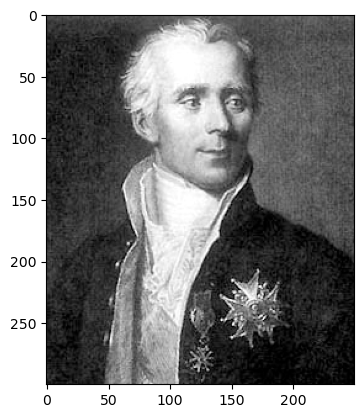

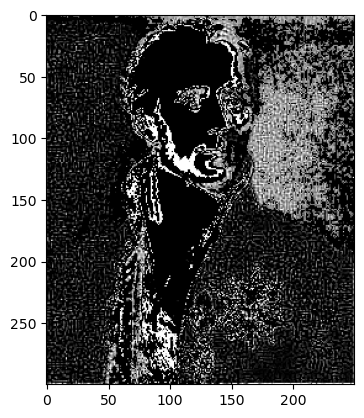

In [29]:
import matplotlib.pyplot as plt
laplace = plt.imread('../images/Laplace-Pierre-Simon.jpg')
laplace_gray = laplace.mean(axis=2)
# laplace_gray = plt.imread('../images/Einstein_tongue.jpg')
plt.figure()
plt.imshow(laplace_gray, cmap='gray') # 载入一张拉普拉斯的黑白图片
laplace_edge = laplacian(laplace, 10)
plt.figure()
plt.imshow(laplace_edge) # 突出显示图片中的边界和轮廓

## the Elastic Mismatch 

(Lin, before Friday)[2]

## the Phase-Field Crystal Model

(Lin, before Sunday)[3]

## the Kirkendall Eq. of Motion

(HY)[4]

## Grain Boundaries and Dislocations

(HY)[5]

[1]: (page 192) NIKOLAS PROVATAS, KEN ELDER. Phase-Field Methods in Materials Science and Engineering[M/OL]. Weinheim, Germany: Wiley-VCH Verlag GmbH & Co. KGaA, 2010[2023-07-12]. http://doi.wiley.com/10.1002/9783527631520. DOI:10.1002/9783527631520.

[2]: (page 81) BINER S B. Programming Phase-Field Modeling[M/OL]. Cham: Springer International Publishing, 2017[2023-11-27]. http://link.springer.com/10.1007/978-3-319-41196-5. DOI:10.1007/978-3-319-41196-5.

[3]: (page 340) BINER S B. Programming Phase-Field Modeling[M/OL]. Cham: Springer International Publishing, 2017[2023-11-27]. http://link.springer.com/10.1007/978-3-319-41196-5. DOI:10.1007/978-3-319-41196-5.

[4]: (Eq. 3, 4) ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.

[5]: (sec. 3.3) ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.
